In [5]:
from transformers import AutoModelForObjectDetection, RTDetrImageProcessor

In [24]:
CHECKPOINT = "PekingU/rtdetr_r101vd"

RT_DETR_PREPROCESSOR = RTDetrImageProcessor.from_pretrained(CHECKPOINT)

rt_detr_model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
)

In [25]:
rt_detr_model

RTDetrForObjectDetection(
  (model): RTDetrModel(
    (backbone): RTDetrConvEncoder(
      (model): RTDetrResNetBackbone(
        (embedder): RTDetrResNetEmbeddings(
          (embedder): Sequential(
            (0): RTDetrResNetConvLayer(
              (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
              (normalization): RTDetrFrozenBatchNorm2d()
              (activation): ReLU()
            )
            (1): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrFrozenBatchNorm2d()
              (activation): ReLU()
            )
            (2): RTDetrResNetConvLayer(
              (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (normalization): RTDetrFrozenBatchNorm2d()
              (activation): ReLU()
            )
          )
          (pooler): MaxPool2d(

# Image encoder

In [26]:
import torch
import torch.nn as nn
from transformers import AutoModelForObjectDetection, RTDetrImageProcessor


class ImageEncoder(nn.Module):
    def __init__(self, backbone, encoder_input_proj, encoder, aggregator):
        super().__init__()
        self.backbone = backbone
        self.encoder_input_proj = encoder_input_proj
        self.encoder = encoder
        self.aggregator = aggregator

    def forward(self, pixel_values, pixel_mask):
        features = self.backbone(pixel_values, pixel_mask)
        projected_features = [self.encoder_input_proj[i](feat[0]) for i, feat in enumerate(features)]
        encoder_outputs = self.encoder(projected_features)
        image_vector = self.aggregator(encoder_outputs)  # [1, 256*3 = 768]

        return image_vector


class FeatureAggregator(nn.Module):
    def __init__(self, output_size=1):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(output_size)

    def forward(self, features):
        pooled = [self.pool(feat) for feat in features.last_hidden_state]
        flattened = [torch.flatten(p, start_dim=1) for p in pooled]
        return torch.cat(flattened, dim=1)


class EnhancedFeatureAggregator(nn.Module):
    def __init__(self):
        super().__init__()
        # Spatial pyramid pooling configurations
        self.pyramid_levels = [1, 2, 4]  # Multi-scale pooling

        # Attention weights for feature scales
        self.scale_attention = nn.Parameter(torch.ones(3))  # For 3 encoder outputs

        # Feature normalization
        self.l2_norm = nn.LayerNorm(384 * sum([l**2 for l in self.pyramid_levels]) * 3)

    def spatial_pyramid_pool(self, x):
        """Captures multi-scale spatial information"""
        pooled_features = []
        for level in self.pyramid_levels:
            h, w = x.shape[2:]
            pool = nn.AdaptiveAvgPool2d((level, level))
            pooled = pool(x)
            pooled_features.append(pooled.flatten(1))
        return torch.cat(pooled_features, dim=1)

    def forward(self, encoder_outputs):
        # 1. Scale-wise attention weighting
        weights = torch.softmax(self.scale_attention, dim=0)
        weighted_features = [w * feat for w, feat in zip(weights, encoder_outputs.last_hidden_state)]

        # 2. Multi-scale spatial pyramid pooling
        pyramid_features = [self.spatial_pyramid_pool(feat) for feat in weighted_features]

        # 3. Concatenate and normalize
        combined = torch.cat(pyramid_features, dim=1)
        return self.l2_norm(combined)

In [27]:
# Extract components for the image encoder
aggregator = FeatureAggregator(output_size=1)
advenced_aggregator = EnhancedFeatureAggregator()
image_encoder = ImageEncoder(
    backbone=rt_detr_model.model.backbone,
    encoder_input_proj=rt_detr_model.model.encoder_input_proj,
    encoder=rt_detr_model.model.encoder,
    aggregator=advenced_aggregator,
)
image_encoder.to("mps")

ImageEncoder(
  (backbone): RTDetrConvEncoder(
    (model): RTDetrResNetBackbone(
      (embedder): RTDetrResNetEmbeddings(
        (embedder): Sequential(
          (0): RTDetrResNetConvLayer(
            (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (normalization): RTDetrFrozenBatchNorm2d()
            (activation): ReLU()
          )
          (1): RTDetrResNetConvLayer(
            (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (normalization): RTDetrFrozenBatchNorm2d()
            (activation): ReLU()
          )
          (2): RTDetrResNetConvLayer(
            (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (normalization): RTDetrFrozenBatchNorm2d()
            (activation): ReLU()
          )
        )
        (pooler): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      )
     

In [28]:
import numpy as np
from PIL import Image

image_names = ["similar_1.jpeg", "similar_2.jpeg", "less_similar.jpeg", "roof.jpg", "diff.jpeg"]

images = [np.array(Image.open(f"./data/{image_name}")) for image_name in image_names]

inputs = RT_DETR_PREPROCESSOR(  # type: ignore[no-any-unimported]
    images=images, return_tensors="pt"
)
pixel_values = inputs["pixel_values"].to("mps")
pixel_mask = torch.ones([len(image_names), 640, 640]).to("mps")

with torch.no_grad():
    encoder_outputs = image_encoder(pixel_values, pixel_mask)

In [29]:
encoder_outputs.shape

torch.Size([5, 24192])

In [30]:
from sklearn.metrics.pairwise import cosine_similarity


def compute_similarities(embs_a, embs_b):
    # Normalize embeddings
    embs_a = embs_a.cpu()
    embs_b = embs_b.cpu()
    norm_a = embs_a / np.linalg.norm(embs_a, axis=1, keepdims=True)
    norm_b = embs_b / np.linalg.norm(embs_b, axis=1, keepdims=True)
    return cosine_similarity(norm_a, norm_b)

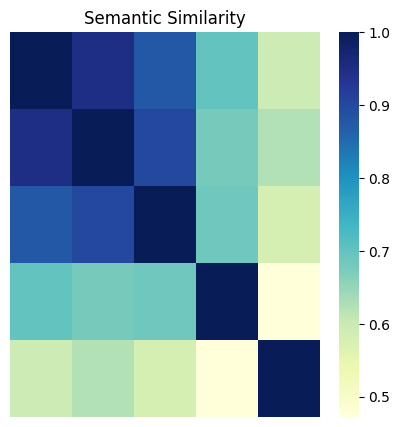

In [31]:
import seaborn as sns
from matplotlib import pyplot as plt

similarity = compute_similarities(encoder_outputs, encoder_outputs)

fig, axes = plt.subplots(1, 1, figsize=(5, 5))
sns.heatmap(similarity, ax=axes, cmap="YlGnBu", xticklabels=False, yticklabels=False)
axes.set_title("Semantic Similarity")
plt.show()

In [32]:
similarity

array([[1.        , 0.9498816 , 0.8768622 , 0.6995966 , 0.59408736],
       [0.9498816 , 1.0000007 , 0.90213925, 0.67956376, 0.62414265],
       [0.8768622 , 0.90213925, 1.0000001 , 0.6869211 , 0.58085686],
       [0.6995966 , 0.67956376, 0.6869211 , 0.99999994, 0.4720933 ],
       [0.59408736, 0.62414265, 0.58085686, 0.4720933 , 1.0000006 ]],
      dtype=float32)

# Sonar

In [33]:
import torch
from torch import nn
from transformers.models.m2m_100.modeling_m2m_100 import M2M100Config, M2M100Encoder


class SonarContextEncoder(nn.Module):
    def __init__(self, image_embed_dim, hidden_dim=1024, num_layers=24):
        super().__init__()

        # Image sequence processing
        self.image_projection = nn.Sequential(
            nn.Linear(image_embed_dim, hidden_dim), nn.GELU(), nn.LayerNorm(hidden_dim)
        )

        # Positional encoding for image sequences
        self.position_embeddings = nn.Embedding(25, hidden_dim)  # Max 512 images per sequence

        # Adapted M2M100 encoder
        config = M2M100Config(
            d_model=hidden_dim,
            encoder_layers=num_layers,
            encoder_ffn_dim=hidden_dim * 8,
            encoder_attention_heads=16,
            max_position_embeddings=25,
        )
        self.encoder = M2M100Encoder(config)

        # Context aggregation
        self.context_projection = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, image_embeddings):
        """
        Args:
            image_embeddings: List of RT-DETR image vectors [batch_size, seq_len, 2688]
        Returns:
            context_embedding: [batch_size, hidden_dim//4]
        """
        # Project image embeddings
        projected = self.image_projection(image_embeddings)  # [bs, seq_len, 1024]

        # Add positional embeddings
        positions = torch.arange(projected.size(1), device=image_embeddings.device).unsqueeze(0)
        position_embeds = self.position_embeddings(positions)
        embeddings = projected + position_embeds

        # Encode sequence
        encoder_outputs = self.encoder(inputs_embeds=embeddings, output_hidden_states=True)

        # Aggregate context
        last_hidden = encoder_outputs.last_hidden_state  # [bs, seq_len, 1024]
        context = self.context_projection(last_hidden.mean(dim=1))  # [bs, 1024]

        return context

In [34]:
# from transformers import AutoTokenizer
#
# model_name = "cointegrated/SONAR_200_text_encoder"
# sonar_encoder = M2M100Encoder.from_pretrained(model_name)
# sonar_encoder.to("mps")
# sonar_tokenizer = AutoTokenizer.from_pretrained(model_name)

import torch
from transformers import NllbTokenizer

from lcm_explo.m2m_100 import M2M100EncoderModel

sonar_encoder = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf").to("mps")
sonar_tokenizer = NllbTokenizer.from_pretrained(
    "facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn"
)

In [35]:
sonar_encoder

M2M100EncoderModel(
  (shared): Embedding(256206, 1024)
  (encoder): M2M100Encoder(
    (embed_tokens): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
    (embed_positions): M2M100SinusoidalPositionalEmbedding()
    (layers): ModuleList(
      (0-23): 24 x M2M100EncoderLayer(
        (self_attn): M2M100SdpaAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (activation_fn): ReLU()
        (fc1): Linear(in_features=1024, out_features=8192, bias=True)
        (fc2): Linear(in_features=8192, out_features=1024, bias=True)
        (final_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      )
    )
    (

In [36]:
# def get_sonar_embeddings(texts):
#     sonar_tokenizer.src_lang = 'eng_Latn'
#     with torch.inference_mode():
#         batch = sonar_tokenizer(texts, return_tensors='pt', padding=True).to("mps")
#         seq_embs = sonar_encoder(**batch).last_hidden_state
#         mask = batc£h.attention_mask
#         mean_emb = (seq_embs * mask.unsqueeze(-1)).sum(1) / mask.unsqueeze(-1).sum(1)
#     return mean_emb


def get_sonar_embeddings(texts, lang="eng_Latn"):
    sonar_tokenizer.src_lang = lang
    inputs = sonar_tokenizer(texts, padding=True, return_tensors="pt").to("mps")
    with torch.inference_mode():
        encoder_out = sonar_encoder(**inputs, pool_last_hidden_state=True)
        embeddings = encoder_out.last_hidden_state.squeeze(1)
    return embeddings

In [37]:
sonar_context_encoder = SonarContextEncoder(24192)
sonar_context_encoder.to("mps")

SonarContextEncoder(
  (image_projection): Sequential(
    (0): Linear(in_features=24192, out_features=1024, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  )
  (position_embeddings): Embedding(25, 1024)
  (encoder): M2M100Encoder(
    (embed_tokens): M2M100ScaledWordEmbedding(128112, 1024, padding_idx=1)
    (embed_positions): M2M100SinusoidalPositionalEmbedding()
    (layers): ModuleList(
      (0-23): 24 x M2M100EncoderLayer(
        (self_attn): M2M100SdpaAttention(
          (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
          (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (activation_fn): ReLU()
        (fc1): Linear(in_featur

In [38]:
with torch.no_grad():
    sonar_outputs = sonar_context_encoder(encoder_outputs.unsqueeze(0))

In [39]:
sonar_outputs.shape

torch.Size([1, 1024])

# Dataset

In [40]:
from datasets import load_dataset

ds = load_dataset("DAMO-NLP-SG/Multi-Source-Video-Captioning", split="train")

In [41]:
from sklearn.model_selection import train_test_split

train_indexes, test_indexes, _, _ = train_test_split(
    list(range(ds.num_rows)), list(range(ds.num_rows)), test_size=0.2, random_state=42
)

train, test = ds[train_indexes], ds[test_indexes]

# Training

In [42]:
import torch
from torch.utils.data import Dataset
from torchvision.io import read_video


class VideoCaptioningDataset(Dataset):
    def __init__(self, root, dataset, image_processor, image_encoder, text_encoder, max_frames=25, frame_size=448):
        """
        Args:
            dataset: Hugging Face dataset (e.g., from `datasets` library)
            image_encoder: Pre-trained RT-DETR-based image encoder
            tokenizer: Pre-trained tokenizer for text (e.g., GPT-2 or BERT)
            max_frames: Maximum number of frames to sample from each video
            frame_size: Size of frames for resizing
        """
        self.root = root
        self.dataset = dataset
        self.image_processor = image_processor
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.max_frames = max_frames
        self.frame_size = frame_size

    def __len__(self):
        return len(self.dataset["video_id"])

    def __getitem__(self, idx):
        # Load video
        video_path = self.dataset["video_path"][idx]
        video_frames, _, _ = read_video(f"{self.root}/{video_path}", pts_unit="sec")  # [T, H, W, C]

        # Sample frames
        frame_indices = torch.linspace(0, len(video_frames) - 1, self.max_frames).long()
        frames = video_frames[frame_indices]  # [max_frames, H, W, C]

        # Preprocess frames
        frames = self.image_processor(frames, return_tensors="pt")["pixel_values"].to("mps")  # [max_frames, C, H, W]
        pixels_mask = torch.ones(frames.shape[0], frames.shape[2], frames.shape[3]).to("mps")

        # Extract image features
        with torch.no_grad():
            image_features = self.image_encoder(frames, pixels_mask)  # [max_frames, feature_dim]

        captions = self.dataset["captions"][idx]
        caption = np.random.choice(captions, size=1).tolist()

        with torch.no_grad():
            target_features = self.text_encoder(caption)

        return {
            "image_features": image_features,  # [max_frames, feature_dim]
            "target_features": target_features.squeeze(0),  # [sonar_feature_dim]
        }


class PreprocessedVideoCaptioningDataset(Dataset):
    def __init__(self, root, dataset):
        """
        Args:
            dataset: Hugging Face dataset (e.g., from `datasets` library)
            image_encoder: Pre-trained RT-DETR-based image encoder
            tokenizer: Pre-trained tokenizer for text (e.g., GPT-2 or BERT)
            max_frames: Maximum number of frames to sample from each video
            frame_size: Size of frames for resizing
        """
        self.root = root
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset["video_id"])

    def __getitem__(self, idx):
        # Load video
        video_path = self.dataset["video_path"][idx]
        video_saving_folder = self.root / Path(video_path).parent / Path(video_path).stem
        image_features = torch.load(video_saving_folder / "image_features.pt")
        target_features = torch.load(video_saving_folder / "target_features.pt")

        return {
            "image_features": image_features,  # [max_frames, feature_dim]
            "target_features": target_features.squeeze(0),  # [sonar_feature_dim]
        }

In [43]:
from pathlib import Path

# train_dataset = VideoCaptioningDataset(
#     root="./data/train/MSVC",
#     dataset=train,
#     image_encoder=image_encoder,
#     image_processor=RT_DETR_PREPROCESSOR,
#     text_encoder=get_sonar_embeddings,
#     max_frames=25,
# )
# val_dataset = VideoCaptioningDataset(
#     root="./data/train/MSVC",
#     dataset=test,
#     image_encoder=image_encoder,
#     image_processor=RT_DETR_PREPROCESSOR,
#     text_encoder=get_sonar_embeddings,
#     max_frames=25,
# )

train_dataset = PreprocessedVideoCaptioningDataset(
    root=Path("./data/train/preprocessed/v1"),
    dataset=train,
)
val_dataset = PreprocessedVideoCaptioningDataset(
    root=Path("./data/train/preprocessed/v1"),
    dataset=test,
)

In [39]:
# from pathlib import Path
# from tqdm import tqdm
#
# SAVING_FOLDER = Path("./data/train/preprocessed/v1")
# SAVING_FOLDER.mkdir(exist_ok=True, parents=True)
#
# for idx in tqdm(range(len(val_dataset))):
#
#     video_path = val_dataset.dataset["video_path"][idx]
#     video_frames, _, _ = read_video(f"{val_dataset.root}/{video_path}", pts_unit="sec")  # [T, H, W, C]
#
#     video_saving_folder = SAVING_FOLDER / Path(video_path).parent / Path(video_path).stem
#     video_saving_folder.mkdir(exist_ok=True, parents=True)
#
#     frame_indices = torch.linspace(0, len(video_frames) - 1, val_dataset.max_frames).long()
#     frames = video_frames[frame_indices]  # [max_frames, H, W, C]
#
#     frames = val_dataset.image_processor(frames, return_tensors="pt")["pixel_values"].to("mps")
#     pixels_mask = torch.ones(frames.shape[0], frames.shape[2], frames.shape[3]).to("mps")
#
#     # Extract image features
#     with torch.no_grad():
#         image_features = val_dataset.image_encoder(frames, pixels_mask)  # [max_frames, feature_dim]
#
#     torch.save(image_features, video_saving_folder / "image_features.pt")
#
#     captions = val_dataset.dataset["captions"][idx]
#     caption = np.random.choice(captions, size=1).tolist()
#
#     with torch.no_grad():
#         target_features = val_dataset.text_encoder(caption)
#
#     torch.save(target_features, video_saving_folder / "target_features.pt")

In [44]:
ds[:].keys()

dict_keys(['video_id', 'question', 'video_path', 'captions'])

In [45]:
ds[:]["video_path"][:10]

['msrvtt/video9921.mp4',
 'msrvtt/video8120.mp4',
 'msrvtt/video7888.mp4',
 'msrvtt/video7953.mp4',
 'msrvtt/video8675.mp4',
 'msrvtt/video7941.mp4',
 'msrvtt/video7018.mp4',
 'msrvtt/video9032.mp4',
 'msrvtt/video8660.mp4',
 'msrvtt/video9107.mp4']

In [46]:
import json

with open("./data/msrvtt/MSRVTT/annotation/MSR_VTT.json") as f:
    msvtt_json = json.load(f)

In [47]:
annotations_mapping = {}
for annotation in msvtt_json["annotations"]:
    image_id = annotation["image_id"]
    if image_id not in annotations_mapping:
        annotations_mapping[image_id] = []
    annotations_mapping[image_id].append(annotation["caption"])

In [58]:
from tqdm import tqdm

new_dataset = {"video_id": ds[:]["video_id"], "video_path": ds[:]["video_path"], "captions": ds[:]["captions"]}

SAVING_FOLDER = Path("./data/train/preprocessed/v1")
SAVING_FOLDER.mkdir(exist_ok=True, parents=True)

for image_info in tqdm(msvtt_json["images"]):
    image_id = image_info["id"]
    video_id = f"msrvtt_{image_id}"

    if video_id not in ds[:]["video_id"]:
        video_path = f"msrvtt/{image_id}.mp4"

        video_frames, _, _ = read_video(f"./data/train/MSVC/{video_path}", pts_unit="sec")  # [T, H, W, C]

        video_saving_folder = SAVING_FOLDER / Path(video_path).parent / Path(video_path).stem
        video_saving_folder.mkdir(exist_ok=True, parents=True)

        frame_indices = torch.linspace(0, len(video_frames) - 1, 25).long()
        frames = video_frames[frame_indices]  # [max_frames, H, W, C]

        frames = RT_DETR_PREPROCESSOR(frames, return_tensors="pt")["pixel_values"].to("mps")
        pixels_mask = torch.ones(frames.shape[0], frames.shape[2], frames.shape[3]).to("mps")

        # Extract image features
        with torch.no_grad():
            image_features = image_encoder(frames, pixels_mask)  # [max_frames, feature_dim]

        torch.save(image_features, video_saving_folder / "image_features.pt")

        captions = annotations_mapping[image_id]
        caption = np.random.choice(captions, size=1).tolist()

        with torch.no_grad():
            target_features = get_sonar_embeddings(caption)

        torch.save(target_features, video_saving_folder / "target_features.pt")

        new_dataset["video_id"].append(video_id)
        new_dataset["video_path"].append(video_path)
        new_dataset["captions"].append(captions)

with open("./data/train/preprocessed/v1/data.json", "w") as f:
    json.dump(new_dataset, f)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [4:48:32<00:00,  1.73s/it]


In [ ]:
from pathlib import Path

from tqdm import tqdm

SAVING_FOLDER = Path("./data/train/preprocessed/v1")
SAVING_FOLDER.mkdir(exist_ok=True, parents=True)

for idx in tqdm(range(len(val_dataset))):
    video_path = val_dataset.dataset["video_path"][idx]
    video_frames, _, _ = read_video(f"{val_dataset.root}/{video_path}", pts_unit="sec")  # [T, H, W, C]

    video_saving_folder = SAVING_FOLDER / Path(video_path).parent / Path(video_path).stem
    video_saving_folder.mkdir(exist_ok=True, parents=True)

    frame_indices = torch.linspace(0, len(video_frames) - 1, val_dataset.max_frames).long()
    frames = video_frames[frame_indices]  # [max_frames, H, W, C]

    frames = val_dataset.image_processor(frames, return_tensors="pt")["pixel_values"].to("mps")
    pixels_mask = torch.ones(frames.shape[0], frames.shape[2], frames.shape[3]).to("mps")

    # Extract image features
    with torch.no_grad():
        image_features = val_dataset.image_encoder(frames, pixels_mask)  # [max_frames, feature_dim]

    torch.save(image_features, video_saving_folder / "image_features.pt")

    captions = val_dataset.dataset["captions"][idx]
    caption = np.random.choice(captions, size=1).tolist()

    with torch.no_grad():
        target_features = val_dataset.text_encoder(caption)

    torch.save(target_features, video_saving_folder / "target_features.pt")

In [40]:
from torch.nn.utils.rnn import pad_sequence


def collate_fn(batch):
    image_features = [item["image_features"] for item in batch]
    target_features = [item["target_features"] for item in batch]

    image_features_padded = pad_sequence(image_features, batch_first=True, padding_value=0)
    target_features_stacked = torch.stack(target_features)

    return {"image_features": image_features_padded, "target_features": target_features_stacked}

In [41]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=4,
    num_workers=0,
    collate_fn=collate_fn,
)

In [42]:
import lightning as pl
import torch.nn.functional as F
from lightning.pytorch.utilities.types import OptimizerLRSchedulerConfig
from torch import Tensor


class RMSELoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, yhat, y):
        loss = torch.sqrt(self.mse(yhat, y) + self.eps)
        return loss


class VideoCaptioningDataModule(pl.LightningModule):
    def __init__(self, model, max_epochs, batch_size, learning_rate=1e-4, weight_decay=1e-5):
        super().__init__()
        self.model = model

        # self.loss = RMSELoss()
        self.temperature = nn.Parameter(torch.tensor(0.07))
        self.loss_fn = nn.KLDivLoss(reduction="batchmean")

        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay

    def configure_optimizers(self):
        param_dicts: Iterable[Dict[str, Any]] = [
            {
                "params": [p for n, p in self.named_parameters() if p.requires_grad],
                "lr": self.learning_rate,
            },
        ]
        optimizer = torch.optim.AdamW(param_dicts, lr=self.learning_rate, weight_decay=self.weight_decay)
        # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, max(1, int(self.max_epochs * 0.1)), 0.7)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1, patience=5, verbose=True
        )
        return OptimizerLRSchedulerConfig(optimizer=optimizer, lr_scheduler=scheduler, monitor="val_loss")

    def distillation_loss(self, student_out, teacher_out):
        student_logits = F.log_softmax(student_out / self.temperature, dim=-1)
        teacher_probs = F.softmax(teacher_out / self.temperature, dim=-1)
        return self.loss_fn(student_logits, teacher_probs)

    def contrastive_loss(self, video_emb, text_emb):
        # Normalize embeddings
        video_emb = F.normalize(video_emb, dim=-1)
        text_emb = F.normalize(text_emb, dim=-1)

        # Compute similarity matrix
        logits = (video_emb @ text_emb.T) * torch.exp(self.temperature)

        # Symmetric loss
        labels = torch.arange(len(logits), device=self.device)
        loss_v2t = F.cross_entropy(logits, labels)
        loss_t2v = F.cross_entropy(logits.T, labels)
        return (loss_v2t + loss_t2v) / 2

    def common_step(self, batch) -> Tensor:
        video_emb = self.model(batch["image_features"])
        text_emb = batch["target_features"]

        # Compute distillation loss
        loss_distill = self.distillation_loss(video_emb, text_emb)

        # Compute contrastive loss
        loss_contrast = self.contrastive_loss(video_emb, text_emb)

        # Total loss
        total_loss = 0.7 * loss_distill + 0.3 * loss_contrast

        return total_loss

    def training_step(self, batch, batch_idx: int) -> Tensor:
        loss = self.common_step(batch)
        self.log(
            "train_loss",
            loss,
            prog_bar=True,
            logger=True,
            on_step=True,
            on_epoch=True,
            batch_size=self.batch_size,
        )
        return loss

    def validation_step(self, batch, batch_idx: int) -> Tensor:
        loss = self.common_step(batch)
        self.log(
            "val_loss",
            loss,
            prog_bar=True,
            logger=True,
            on_step=True,
            on_epoch=True,
            batch_size=self.batch_size,
        )
        return loss

In [43]:
epoch = 10

sonar_context_encoder.train()
model = VideoCaptioningDataModule(sonar_context_encoder, max_epochs=epoch, batch_size=4)
model.to("mps")

VideoCaptioningDataModule(
  (model): SonarContextEncoder(
    (image_projection): Sequential(
      (0): Linear(in_features=24192, out_features=1024, bias=True)
      (1): GELU(approximate='none')
      (2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (position_embeddings): Embedding(25, 1024)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(128112, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-23): 24 x M2M100EncoderLayer(
          (self_attn): M2M100SdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_af

In [ ]:
trainer = pl.Trainer(max_epochs=epoch, accelerator="gpu", devices=1)  # , logger=logger)
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/yann.hallouard/PycharmProjects/personal/lcm-explo/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name  | Type                | Params | Mode 
------------------------------------------------------
0 | model | SonarContextEncoder | 662 M  | train
1 | loss  | RMSELoss            | 0      | train
------------------------------------------------------
662 M     Trainable params
0         Non-trainable 

Sanity Checking: |                                                                                            …

/Users/yann.hallouard/PycharmProjects/personal/lcm-explo/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/Users/yann.hallouard/PycharmProjects/personal/lcm-explo/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Training: |                                                                                                   …


Detected KeyboardInterrupt, attempting graceful shutdown ...


In [147]:
metrics

,train_loss,val_contrast,val_distill,val_loss,val_mse
epoch,,,,,
0,3.590665,NaN,NaN,NaN,NaN
0,3.495190,NaN,NaN,NaN,NaN
0,3.820266,NaN,NaN,NaN,NaN
0,3.604331,NaN,NaN,NaN,NaN
0,3.561185,NaN,NaN,NaN,NaN
...,...,...,...,...,...
24,0.829615,NaN,NaN,NaN,NaN
24,0.833918,NaN,NaN,NaN,NaN
24,0.829779,NaN,NaN,NaN,NaN


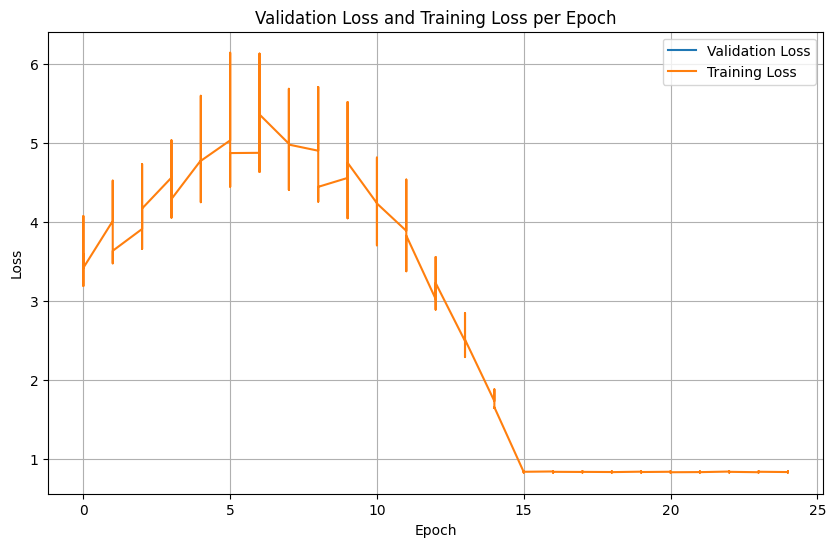

In [146]:
import matplotlib.pyplot as plt
import pandas as pd

metrics = pd.read_csv("../lightning_logs/version_32/metrics.csv")
metrics = metrics[metrics["train_loss"].notna() + metrics["val_loss"].notna()]
metrics = metrics.groupby("step").first()


metrics = metrics.set_index("epoch")

plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.plot(metrics.index, metrics["val_loss"], label="Validation Loss")
plt.plot(metrics.index, metrics["train_loss"], label="Training Loss")

# Add labels and title
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss and Training Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
model = VideoCaptioningDataModule.load_from_checkpoint(
    checkpoint_path="/Users/yann.hallouard/PycharmProjects/personal/lcm-explo/notebooks/data/checkpoints/2025-03-29_19-23-04/epoch=22-step=6900.ckpt",
    model=sonar_context_encoder,
    max_epochs=1,
    batch_size=4,
)
model.eval()

VideoCaptioningDataModule(
  (model): SonarContextEncoder(
    (image_projection): Sequential(
      (0): Linear(in_features=24192, out_features=1024, bias=True)
      (1): GELU(approximate='none')
      (2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    )
    (position_embeddings): Embedding(25, 1024)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(128112, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-23): 24 x M2M100EncoderLayer(
          (self_attn): M2M100SdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_af

In [100]:
idx = 90
batch = train_dataset[idx]
print(train_dataset.dataset["video_path"][idx])

msvd/rw9h_574HxE_70_74.avi


In [101]:
batch["target_features"]

tensor([ 4.4277e-03, -8.9075e-05, -6.1970e-03,  ..., -5.5907e-03,
         3.9501e-03, -6.0871e-03], device='mps:0')

In [102]:
image_features = batch["image_features"].unsqueeze(0).to("mps")
image_features

tensor([[[ 0.4722,  0.2151,  1.1399,  ...,  1.1605,  0.8177,  1.5584],
         [ 0.4692,  0.0206,  1.0423,  ...,  0.9254,  1.0368,  1.3089],
         [ 0.4269,  0.2933,  1.1489,  ...,  0.9373,  1.0365,  1.6568],
         ...,
         [ 0.3545, -0.0977,  0.9156,  ...,  1.0641,  1.0457,  1.6666],
         [ 0.3893, -0.1860,  0.7825,  ...,  1.0284,  1.0943,  1.6373],
         [ 0.3822, -0.2480,  0.8699,  ...,  0.7263,  0.8625,  0.9022]]],
       device='mps:0')

In [103]:
model.model.to("mps")
embedding = model.model(image_features)
embedding

tensor([[ 0.0129,  0.0054,  0.0089,  ..., -0.0044,  0.0083, -0.0143]],
       device='mps:0', grad_fn=<LinearBackward0>)

In [104]:
from transformers.modeling_outputs import BaseModelOutput

from lcm_explo.m2m_100 import M2M100DecoderModel

decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf").to("mps")

# Decoding into the original (English) language
generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=embedding.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("eng_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
print(text_out)  # ["My name is SONAR.", "I can embed the sentences into vector space."]

# Decoding into some other (French) language
generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=embedding.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("fra_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
print(text_out)  # ['Mon nom est SONAR.', "Je peux intégrer les phrases dans l'espace vectoriel."]

['Around the same time, a man and a woman were riding alongside each other on']
["À l'époque, un homme et une femme voyageaient à vélo sur"]


In [105]:
# Decoding into some other (French) language
last_hidden_state = batch["target_features"].unsqueeze(0).unsqueeze(0).detach().to("mps")
generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=last_hidden_state),
    num_beams=5,
    forced_bos_token_id=sonar_tokenizer.convert_tokens_to_ids("fra_Latn"),
)
text_out = sonar_tokenizer.batch_decode(generator_out, skip_special_tokens=True)
print(text_out)  # ['Mon nom est SONAR.', "Je peux intégrer les phrases dans l'espace vectoriel."]

['un homme et une femme montent ensemble sur un vélo']


In [57]:
import torch
from transformers import NllbTokenizer

from lcm_explo.m2m_100 import M2M100EncoderModel

encoder = M2M100EncoderModel.from_pretrained("cointegrated/SONAR_200_text_encoder_hf")
tokenizer = NllbTokenizer.from_pretrained("facebook/nllb-200-distilled-600M", src_lang="eng_Latn", tgt_lang="eng_Latn")

sentences = ["hello, how are you ?"]

inputs = tokenizer(sentences, padding=True, return_tensors="pt")
with torch.inference_mode():
    encoder_out = encoder(**inputs, pool_last_hidden_state=True)
    embeddings = encoder_out.last_hidden_state.squeeze(1)

print(embeddings.shape)

torch.Size([1, 1024])


In [12]:
from transformers.modeling_outputs import BaseModelOutput

from lcm_explo.m2m_100 import M2M100DecoderModel

decoder = M2M100DecoderModel.from_pretrained("cointegrated/SONAR_200_text_decoder_hf")

# Decoding into the original (English) language
generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=embeddings.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=tokenizer.convert_tokens_to_ids("eng_Latn"),
)
text_out = tokenizer.batch_decode(generator_out, skip_special_tokens=True)
print(text_out)  # ["My name is SONAR.", "I can embed the sentences into vector space."]

# Decoding into some other (French) language
generator_out = decoder.generate(
    # passing encoder_outputs is not recommended, because beam search decoding modifies them in place, which is ugly
    # encoder_outputs=enc_out,
    encoder_outputs=BaseModelOutput(last_hidden_state=embeddings.unsqueeze(1)),
    num_beams=5,
    forced_bos_token_id=tokenizer.convert_tokens_to_ids("fra_Latn"),
)
text_out = tokenizer.batch_decode(generator_out, skip_special_tokens=True)
print(text_out)  # ['Mon nom est SONAR.', "Je peux intégrer les phrases dans l'espace vectoriel."]

['hello, how are you?']
['Bonjour, comment allez-vous ?']
